# Data Warehouse: Large Cars

**Proyek UTS Business Intelligence — ETL & Star Schema**

Notebook ini memuat proses lengkap **Extract, Transform, Load (ETL)** untuk membangun data warehouse dari dataset Large Cars (Kaggle). Output berupa star schema dengan tabel dimensi dan fakta yang siap untuk analisis bisnis.

**Alur:** Setup → Extract → Transform → Load → Analisis

# 📦 **1. Install & Import Library**

## 1.1 Install library yang dibutuhkan

In [307]:
import pandas as pd
import sqlite3
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
%matplotlib inline

# 📥 **2. Upload & Extract Data**

## 2.1 Upload file CSV

In [308]:
df = pd.read_csv('/content/Large Cars Dataset.csv')
print(df.shape)
df.head()

(428, 15)


,Brand,Model,VehicleClass,Region,DriveTrain,MSRP,DealerCost,EngineSize,Cylinders,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,"$36,945","$33,337",3.5,6.0,265,17,23,4451,106,189
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,"$23,820","$21,761",2.0,4.0,200,24,31,2778,101,172
2,Acura,TSX 4dr,Sedan,Asia,Front,"$26,990","$24,647",2.4,4.0,200,22,29,3230,105,183
3,Acura,TL 4dr,Sedan,Asia,Front,"$33,195","$30,299",3.2,6.0,270,20,28,3575,108,186
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,"$43,755","$39,014",3.5,6.0,225,18,24,3880,115,197


# 🧹 **3. Cleaning Data**

## 3.1 Baca CSV

In [309]:
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].str.strip()

print("Cek missing values setelah cleaning:")
print(df.isnull().sum())
print("\nSample data bersih:")
df.head()

Cek missing values setelah cleaning:
Brand           0
Model           0
VehicleClass    0
Region          0
DriveTrain      0
MSRP            0
DealerCost      0
EngineSize      0
Cylinders       2
HorsePower      0
MPG_City        0
MPG_Highway     0
Weight          0
Wheelbase       0
Length          0
dtype: int64

Sample data bersih:


,Brand,Model,VehicleClass,Region,DriveTrain,MSRP,DealerCost,EngineSize,Cylinders,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,"$36,945","$33,337",3.5,6.0,265,17,23,4451,106,189
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,"$23,820","$21,761",2.0,4.0,200,24,31,2778,101,172
2,Acura,TSX 4dr,Sedan,Asia,Front,"$26,990","$24,647",2.4,4.0,200,22,29,3230,105,183
3,Acura,TL 4dr,Sedan,Asia,Front,"$33,195","$30,299",3.2,6.0,270,20,28,3575,108,186
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,"$43,755","$39,014",3.5,6.0,225,18,24,3880,115,197


## 3.3 Cleaning

In [310]:
df = pd.read_csv('/content/Large Cars Dataset.csv')
print("Shape awal:", df.shape)
print("\nMissing values sebelum cleaning:")
print(df.isnull().sum())

df['MSRP'] = df['MSRP'].str.replace(r'[$,\s]', '', regex=True).astype(int)
df['DealerCost'] = df['DealerCost'].str.replace(r'[$,\s]', '', regex=True).astype(int)

df['Cylinders'] = df['Cylinders'].fillna(0).astype(int)

str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].str.strip()

df = df.drop_duplicates()

print("\nMissing values setelah cleaning:")
print(df.isnull().sum())
print("\nTipe data setelah cleaning:")
print(df.dtypes)
print("\nShape akhir:", df.shape)
print("\nSample data bersih:")
df.head()

Shape awal: (428, 15)

Missing values sebelum cleaning:
Brand           0
Model           0
VehicleClass    0
Region          0
DriveTrain      0
MSRP            0
DealerCost      0
EngineSize      0
Cylinders       2
HorsePower      0
MPG_City        0
MPG_Highway     0
Weight          0
Wheelbase       0
Length          0
dtype: int64

Missing values setelah cleaning:
Brand           0
Model           0
VehicleClass    0
Region          0
DriveTrain      0
MSRP            0
DealerCost      0
EngineSize      0
Cylinders       0
HorsePower      0
MPG_City        0
MPG_Highway     0
Weight          0
Wheelbase       0
Length          0
dtype: int64

Tipe data setelah cleaning:
Brand            object
Model            object
VehicleClass     object
Region           object
DriveTrain       object
MSRP              int64
DealerCost        int64
EngineSize      float64
Cylinders         int64
HorsePower        int64
MPG_City          int64
MPG_Highway       int64
Weight            int64
Whe

,Brand,Model,VehicleClass,Region,DriveTrain,MSRP,DealerCost,EngineSize,Cylinders,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,36945,33337,3.5,6,265,17,23,4451,106,189
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,23820,21761,2.0,4,200,24,31,2778,101,172
2,Acura,TSX 4dr,Sedan,Asia,Front,26990,24647,2.4,4,200,22,29,3230,105,183
3,Acura,TL 4dr,Sedan,Asia,Front,33195,30299,3.2,6,270,20,28,3575,108,186
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,43755,39014,3.5,6,225,18,24,3880,115,197


## 3.2 Cek

In [311]:
df['Cylinders'] = df['Cylinders'].fillna(0).astype(int)

str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].str.strip()

print("Cek missing values cleaning:")
print(df.isnull().sum())
print("\nSample data bersih:")
df.head()

Cek missing values cleaning:
Brand           0
Model           0
VehicleClass    0
Region          0
DriveTrain      0
MSRP            0
DealerCost      0
EngineSize      0
Cylinders       0
HorsePower      0
MPG_City        0
MPG_Highway     0
Weight          0
Wheelbase       0
Length          0
dtype: int64

Sample data bersih:


,Brand,Model,VehicleClass,Region,DriveTrain,MSRP,DealerCost,EngineSize,Cylinders,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,36945,33337,3.5,6,265,17,23,4451,106,189
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,23820,21761,2.0,4,200,24,31,2778,101,172
2,Acura,TSX 4dr,Sedan,Asia,Front,26990,24647,2.4,4,200,22,29,3230,105,183
3,Acura,TL 4dr,Sedan,Asia,Front,33195,30299,3.2,6,270,20,28,3575,108,186
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,43755,39014,3.5,6,225,18,24,3880,115,197


# 🏗️ **4. Tabel Dimensi & Fakta (Transform Lanjut)**

## 4.1 Dimensi Brand + Region

In [312]:
dim_brand = df[['Brand', 'Region']].drop_duplicates().reset_index(drop=True)
dim_brand['brand_id'] = dim_brand.index + 1
print("dim_brand:", dim_brand.shape)
dim_brand.head()

dim_brand: (38, 3)


,Brand,Region,brand_id
0,Acura,Asia,1
1,Audi,Europe,2
2,BMW,Europe,3
3,Buick,USA,4
4,Cadillac,USA,5


## 4.2 Dimensi Vehicle Class

In [313]:
dim_vehicle_class = df[['VehicleClass']].drop_duplicates().reset_index(drop=True)
dim_vehicle_class['class_id'] = dim_vehicle_class.index + 1
print("dim_vehicle_class:", dim_vehicle_class.shape)
dim_vehicle_class

dim_vehicle_class: (6, 2)


,VehicleClass,class_id
0,SUV,1
1,Sedan,2
2,Sports,3
3,Wagon,4
4,Truck,5
5,Hybrid,6


## 4.3 Dimensi DriveTrain

In [314]:
dim_drivetrain = df[['DriveTrain']].drop_duplicates().reset_index(drop=True)
dim_drivetrain['drive_id'] = dim_drivetrain.index + 1
print("dim_drivetrain:", dim_drivetrain.shape)
dim_drivetrain

dim_drivetrain: (3, 2)


,DriveTrain,drive_id
0,All,1
1,Front,2
2,Rear,3


## 4.4 Tabel Fakta

In [315]:
fact = (df
    .merge(dim_brand, on=['Brand', 'Region'])
    .merge(dim_vehicle_class, on='VehicleClass')
    .merge(dim_drivetrain, on='DriveTrain'))

fact_cars = fact[['brand_id', 'class_id', 'drive_id', 'Model',
                  'MSRP', 'DealerCost', 'EngineSize', 'Cylinders',
                  'HorsePower', 'MPG_City', 'MPG_Highway',
                  'Weight', 'Wheelbase', 'Length']].copy()
fact_cars.insert(0, 'car_id', range(1, len(fact_cars) + 1))

print("fact_cars:", fact_cars.shape)
fact_cars.head()

fact_cars: (428, 15)


,car_id,brand_id,class_id,drive_id,Model,MSRP,DealerCost,EngineSize,Cylinders,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,1,1,1,1,MDX,36945,33337,3.5,6,265,17,23,4451,106,189
1,2,1,2,2,RSX Type S 2dr,23820,21761,2.0,4,200,24,31,2778,101,172
2,3,1,2,2,TSX 4dr,26990,24647,2.4,4,200,22,29,3230,105,183
3,4,1,2,2,TL 4dr,33195,30299,3.2,6,270,20,28,3575,108,186
4,5,1,2,2,3.5 RL 4dr,43755,39014,3.5,6,225,18,24,3880,115,197


# 🗄️ **5. Load ke Data Warehouse (SQLite)**

## 5.1 Koneksi ke SQLite sebagai Data Warehouse

In [316]:
conn = sqlite3.connect('cars_dw.db')

## 5.2 Load semua tabel

In [317]:
dim_brand.to_sql('dim_brand', conn, if_exists='replace', index=False)
dim_vehicle_class.to_sql('dim_vehicle_class', conn, if_exists='replace', index=False)
dim_drivetrain.to_sql('dim_drivetrain', conn, if_exists='replace', index=False)
fact_cars.to_sql('fact_cars', conn, if_exists='replace', index=False)

conn.commit()
print("✅ Data Warehouse berhasil dibuat!")

✅ Data Warehouse berhasil dibuat!


## 5.3 Verifikasi isi Data Warehouse

In [318]:
for tbl in ['dim_brand', 'dim_vehicle_class', 'dim_drivetrain', 'fact_cars']:
    n = pd.read_sql(f"SELECT COUNT(*) as n FROM {tbl}", conn).iloc[0, 0]
    print(f"  {tbl}: {n} rows")

  dim_brand: 38 rows
  dim_vehicle_class: 6 rows
  dim_drivetrain: 3 rows
  fact_cars: 428 rows


# 🔍 **6. Analisis Data (Query SQL)**

## 6.1 Query 1: Top 10 Brand by Avg MSRP

In [319]:
q1 = pd.read_sql("""
    SELECT b.Brand, ROUND(AVG(f.MSRP), 0) as Avg_MSRP, COUNT(*) as Total_Models
    FROM fact_cars f
    JOIN dim_brand b ON f.brand_id = b.brand_id
    GROUP BY b.Brand
    ORDER BY Avg_MSRP DESC
    LIMIT 10
""", conn)
print("Top 10 Brand by Avg MSRP:")
q1

Top 10 Brand by Avg MSRP:


,Brand,Avg_MSRP,Total_Models
0,Porsche,83565.0,7
1,Jaguar,61580.0,12
2,Mercedes-Benz,60657.0,26
3,Cadillac,50474.0,8
4,Hummer,49995.0,1
5,Land Rover,45832.0,3
6,Lexus,44215.0,11
7,Audi,43308.0,19
8,BMW,43285.0,20
9,Acura,42939.0,7


## 6.2 Query 2: Avg MPG per Vehicle Class

In [320]:
q2 = pd.read_sql("""
    SELECT vc.VehicleClass,
           ROUND(AVG(f.MPG_City), 1) as Avg_MPG_City,
           ROUND(AVG(f.MPG_Highway), 1) as Avg_MPG_Highway
    FROM fact_cars f
    JOIN dim_vehicle_class vc ON f.class_id = vc.class_id
    GROUP BY vc.VehicleClass
    ORDER BY Avg_MPG_City DESC
""", conn)
print("Avg MPG per Vehicle Class:")
q2

Avg MPG per Vehicle Class:


,VehicleClass,Avg_MPG_City,Avg_MPG_Highway
0,Hybrid,55.0,56.0
1,Wagon,21.1,27.9
2,Sedan,21.1,28.6
3,Sports,18.4,25.5
4,Truck,16.5,21.0
5,SUV,16.1,20.5


## 6.3 Query 3: Stats per Region

In [321]:
q3 = pd.read_sql("""
    SELECT b.Region,
           COUNT(*) as Total_Models,
           ROUND(AVG(f.MSRP), 0) as Avg_MSRP,
           ROUND(AVG(f.HorsePower), 1) as Avg_HP
    FROM fact_cars f
    JOIN dim_brand b ON f.brand_id = b.brand_id
    GROUP BY b.Region
""", conn)
print("Stats per Region:")
q3

Stats per Region:


,Region,Total_Models,Avg_MSRP,Avg_HP
0,Asia,158,24741.0,190.7
1,Europe,123,48350.0,251.9
2,USA,147,28377.0,212.8


## 6.4 Query 4: Top 10 Mobil Paling Bertenaga

In [322]:
q4 = pd.read_sql("""
    SELECT b.Brand, f.Model, f.HorsePower, f.MSRP
    FROM fact_cars f
    JOIN dim_brand b ON f.brand_id = b.brand_id
    ORDER BY f.HorsePower DESC
    LIMIT 10
""", conn)
print("Top 10 Mobil Paling Bertenaga:")
q4

Top 10 Mobil Paling Bertenaga:


,Brand,Model,HorsePower,MSRP
0,Dodge,Viper SRT-10 convertible 2dr,500,81795
1,Mercedes-Benz,CL600 2dr,493,128420
2,Mercedes-Benz,SL55 AMG 2dr,493,121770
3,Mercedes-Benz,SL600 convertible 2dr,493,126670
4,Porsche,911 GT2 2dr,477,192465
5,Audi,RS 6 4dr,450,84600
6,Volkswagen,Phaeton W12 4dr,420,75000
7,Jaguar,S-Type R 4dr,390,63120
8,Jaguar,XJR 4dr,390,74995
9,Jaguar,XKR coupe 2dr,390,81995


## 6.5 Query 5: Distribusi DriveTrain

In [323]:
q5 = pd.read_sql("""
    SELECT d.DriveTrain, COUNT(*) as Count,
           ROUND(AVG(f.MSRP), 0) as Avg_MSRP
    FROM fact_cars f
    JOIN dim_drivetrain d ON f.drive_id = d.drive_id
    GROUP BY d.DriveTrain
""", conn)
print("Distribusi DriveTrain:")
q5

Distribusi DriveTrain:


,DriveTrain,Count,Avg_MSRP
0,All,92,36483.0
1,Front,226,24783.0
2,Rear,110,46094.0


# 📊 **7. Visualisasi Data**

In [324]:
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#F8F9FA')
plt.suptitle('Cars Data Warehouse – Analisis Data', fontsize=20, fontweight='bold', y=0.98)

Text(0.5, 0.98, 'Cars Data Warehouse – Analisis Data')

<Figure size 1800x1400 with 0 Axes>

## 7.1 Horizontal Bar Chart — Top 10 Brand by Avg MSRP

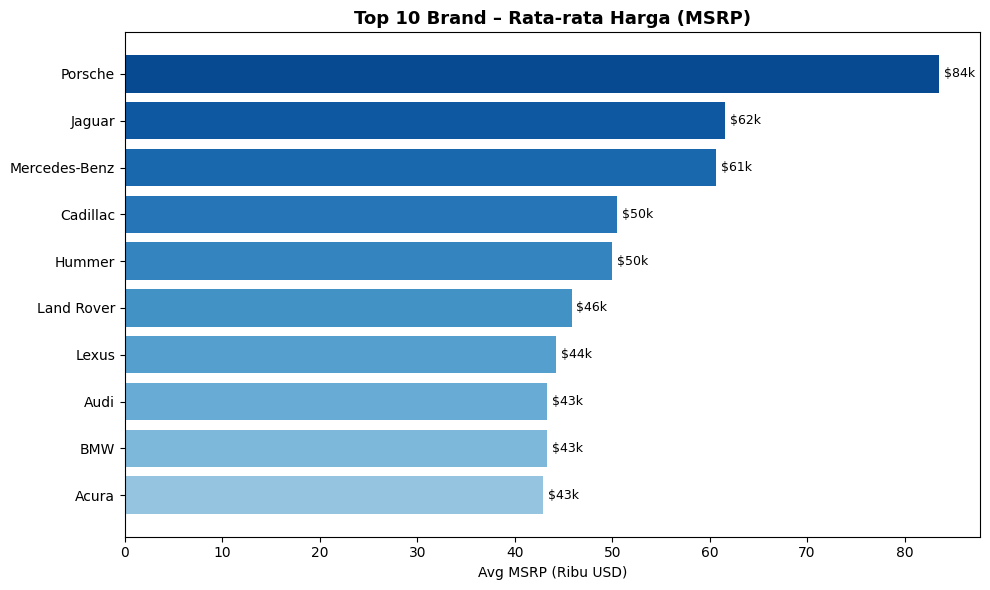

In [325]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(q1)))[::-1]
bars = ax.barh(q1['Brand'], q1['Avg_MSRP'] / 1000, color=colors)
ax.set_xlabel('Avg MSRP (Ribu USD)')
ax.set_title('Top 10 Brand – Rata-rata Harga (MSRP)', fontweight='bold', fontsize=13)
ax.invert_yaxis()
for bar, val in zip(bars, q1['Avg_MSRP']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'${val/1000:.0f}k', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7.2 Grouped Bar Chart — Avg MPG City vs Highway per Kelas

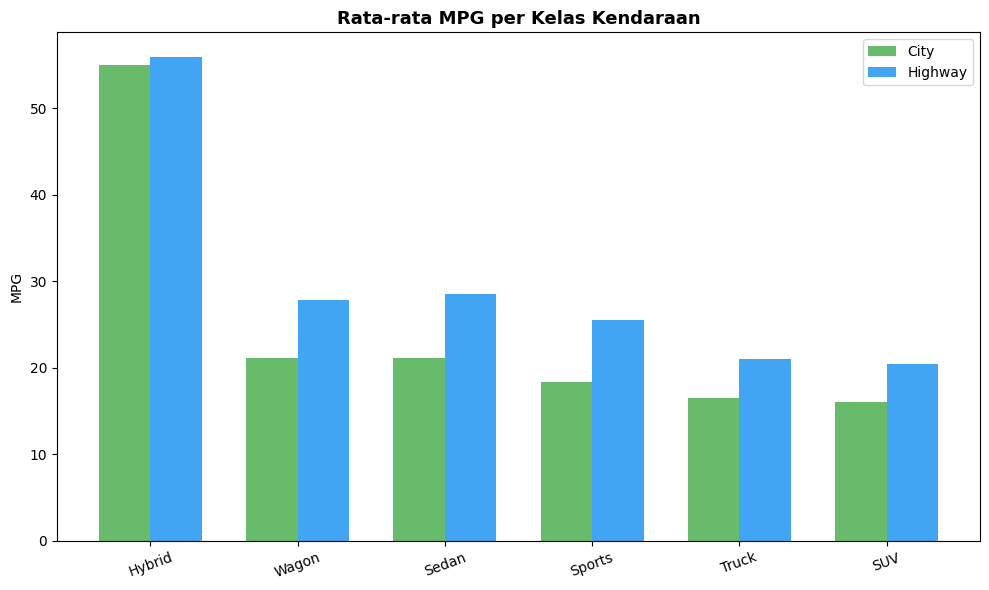

In [326]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(q2))
w = 0.35
ax.bar(x - w/2, q2['Avg_MPG_City'], w, label='City', color='#4CAF50', alpha=0.85)
ax.bar(x + w/2, q2['Avg_MPG_Highway'], w, label='Highway', color='#2196F3', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(q2['VehicleClass'], rotation=20, fontsize=10)
ax.set_ylabel('MPG')
ax.set_title('Rata-rata MPG per Kelas Kendaraan', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 7.3 Pie Chart — Distribusi Model per Region

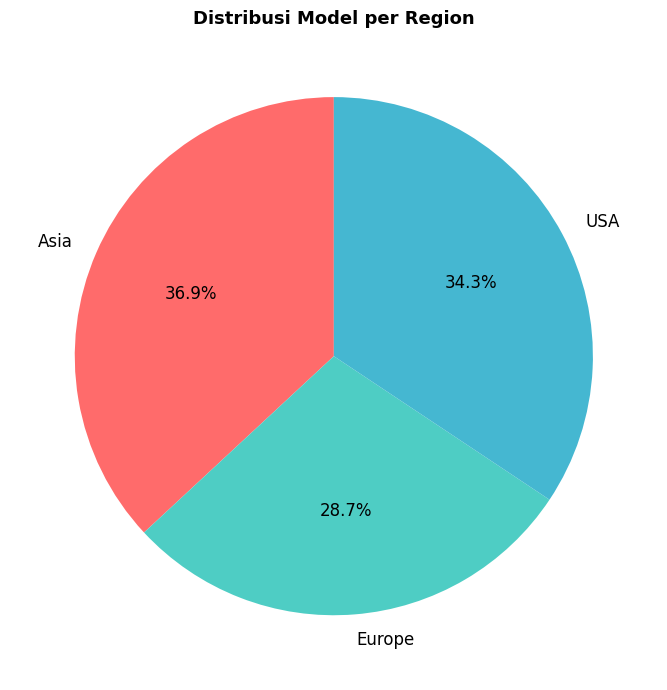

In [327]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(q3['Total_Models'], labels=q3['Region'], autopct='%1.1f%%',
       colors=['#FF6B6B', '#4ECDC4', '#45B7D1'], startangle=90,
       textprops={'fontsize': 12})
ax.set_title('Distribusi Model per Region', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 7.4 Bar Chart — Avg MSRP per DriveTrain

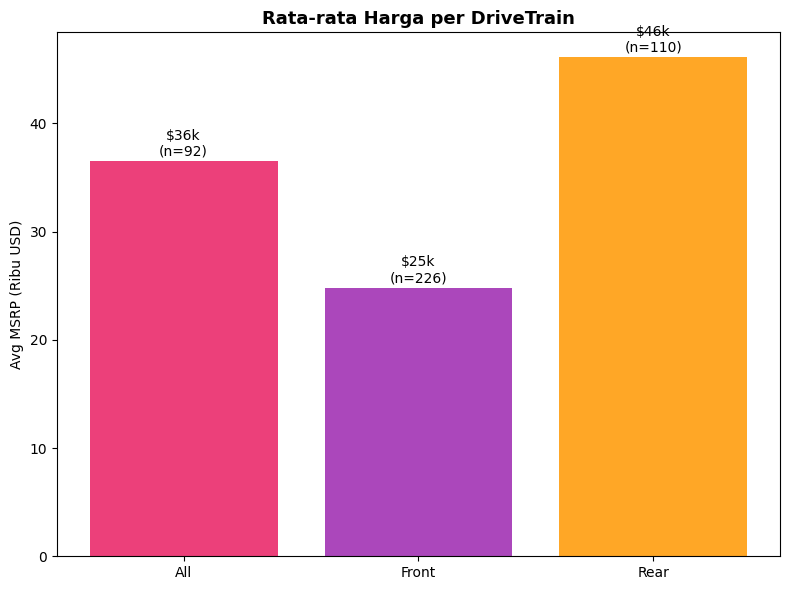

In [328]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(q5['DriveTrain'], q5['Avg_MSRP'] / 1000,
       color=['#E91E63', '#9C27B0', '#FF9800'], alpha=0.85)
ax.set_ylabel('Avg MSRP (Ribu USD)')
ax.set_title('Rata-rata Harga per DriveTrain', fontweight='bold', fontsize=13)
for i, (val, cnt) in enumerate(zip(q5['Avg_MSRP'], q5['Count'])):
    ax.text(i, val/1000 + 0.5, f'${val/1000:.0f}k\n(n={cnt})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 7.5 Scatter Plot — HorsePower vs MSRP

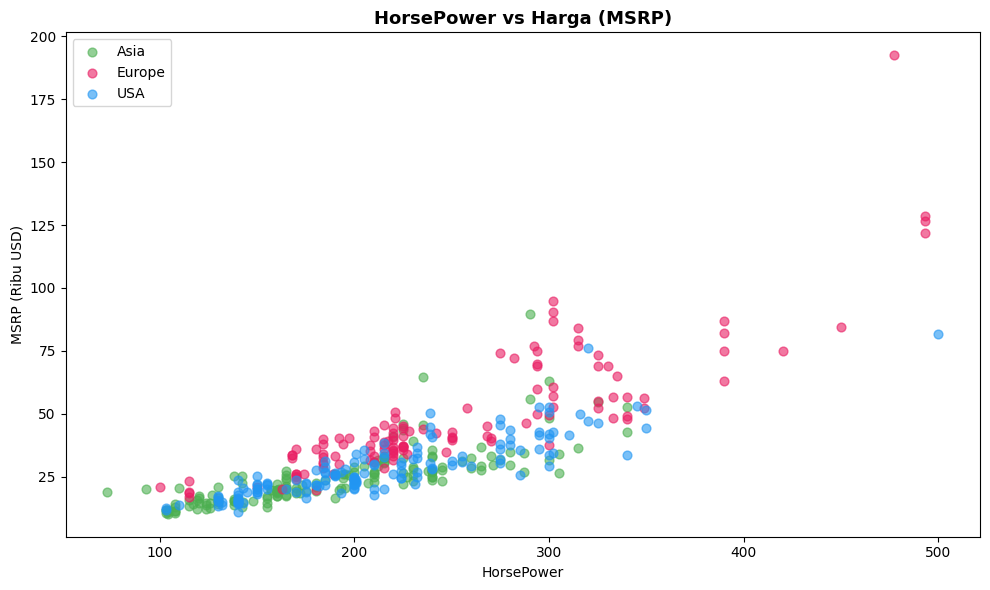

In [329]:
df_plot = pd.read_sql("""
    SELECT f.HorsePower, f.MSRP, b.Region
    FROM fact_cars f JOIN dim_brand b ON f.brand_id = b.brand_id
""", conn)

fig, ax = plt.subplots(figsize=(10, 6))
region_colors = {'Asia': '#4CAF50', 'Europe': '#E91E63', 'USA': '#2196F3'}
for region, grp in df_plot.groupby('Region'):
    ax.scatter(grp['HorsePower'], grp['MSRP'] / 1000,
               label=region, alpha=0.6, s=40, color=region_colors[region])
ax.set_xlabel('HorsePower')
ax.set_ylabel('MSRP (Ribu USD)')
ax.set_title('HorsePower vs Harga (MSRP)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7.6 Bar Chart — Avg HorsePower per Region

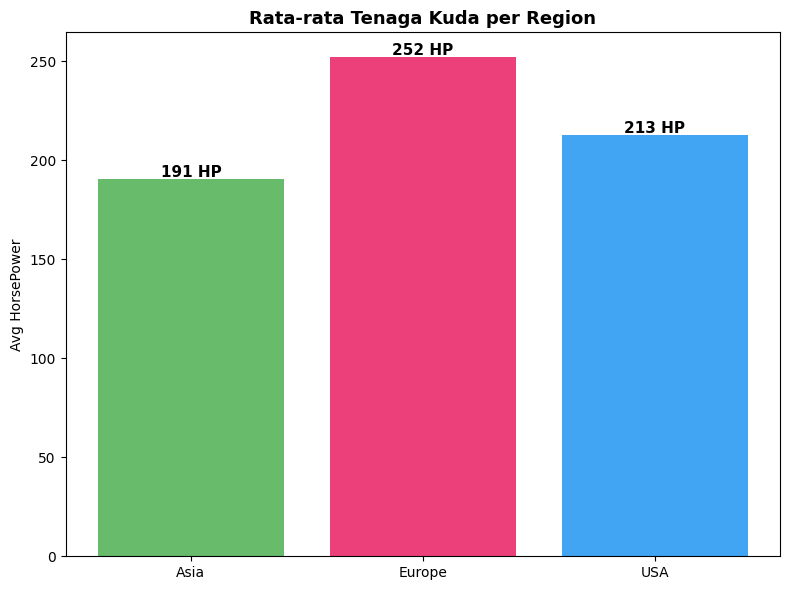

In [330]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(q3['Region'], q3['Avg_HP'],
       color=['#4CAF50', '#E91E63', '#2196F3'], alpha=0.85)
ax.set_ylabel('Avg HorsePower')
ax.set_title('Rata-rata Tenaga Kuda per Region', fontweight='bold', fontsize=13)
for i, val in enumerate(q3['Avg_HP']):
    ax.text(i, val + 1, f'{val:.0f} HP', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [331]:
# Download
from google.colab import files

files.download('cars_dw.db')
files.download('analysis_charts.png')
print("✅ File berhasil didownload!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File berhasil didownload!
